In [1]:
import pandas as pd

In [2]:
# -------------------- LOAD DATA --------------------
ds = pd.read_csv("Real estate.csv")
print(ds.head())

   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98746     121.54391  

In [6]:

# -------------------- BASIC INFO --------------------
print(ds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None


In [7]:

# -------------------- DROP USELESS COLUMN --------------------
ds.drop("No", axis=1, inplace=True)

In [8]:
# -------------------- CHECK NULLS --------------------
print(ds.isnull().sum())

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [9]:
# -------------------- FEATURES & TARGET --------------------
X = ds.drop("Y house price of unit area", axis=1)
y = ds["Y house price of unit area"]

In [10]:
# -------------------- TRAIN TEST SPLIT --------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
# -------------------- MODEL --------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# -------------------- COEFFICIENTS --------------------
print("\nModel Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")

print("Intercept:", model.intercept_)


Model Coefficients:
X1 transaction date: 5.440741856695853
X2 house age: -0.2707914899624968
X3 distance to the nearest MRT station: -0.004758638917293966
X4 number of convenience stores: 1.091425267691967
X5 latitude: 229.04305381550012
X6 longitude: -29.49259077619819
Intercept: -13044.231917160545


In [13]:
# -------------------- TRAIN PERFORMANCE --------------------
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

y_pred_train = model.predict(X_train)

print("\n--- Training Performance ---")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))



--- Training Performance ---
MSE: 83.11348248899759
RMSE: 9.116659612434677
R2 Score: 0.558119727460701


In [14]:
# -------------------- TEST PERFORMANCE --------------------
y_pred_test = model.predict(X_test)

print("\n--- Testing Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R2 Score:", r2_score(y_test, y_pred_test))


--- Testing Performance ---
MSE: 53.50561912450305
R2 Score: 0.6810580555095888


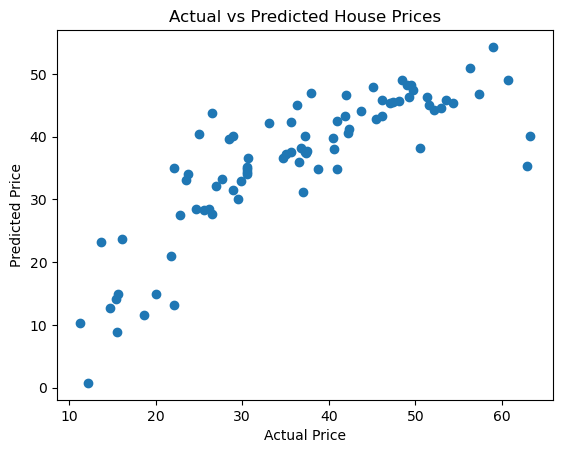

In [15]:
# -------------------- VISUALIZATION --------------------
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [20]:
# Convert to DataFrame (IMPORTANT)
input_data = pd.DataFrame([{
    "X1 transaction date": x1,
    "X2 house age": x2,
    "X3 distance to the nearest MRT station": x3,
    "X4 number of convenience stores": x4,
    "X5 latitude": x5,
    "X6 longitude": x6
}])

prediction = model.predict(input_data)

print("\nPredicted House Price:", round(prediction[0], 2))


Predicted House Price: 23887.21
